In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import xgboost as xgb
import shap


## 3.  Exploratory Data Analysis (EDA)

### 3.1 Distributions of Key Numeric Features


In [15]:
df = pd.read_csv("../data/credit_cleaned.csv")

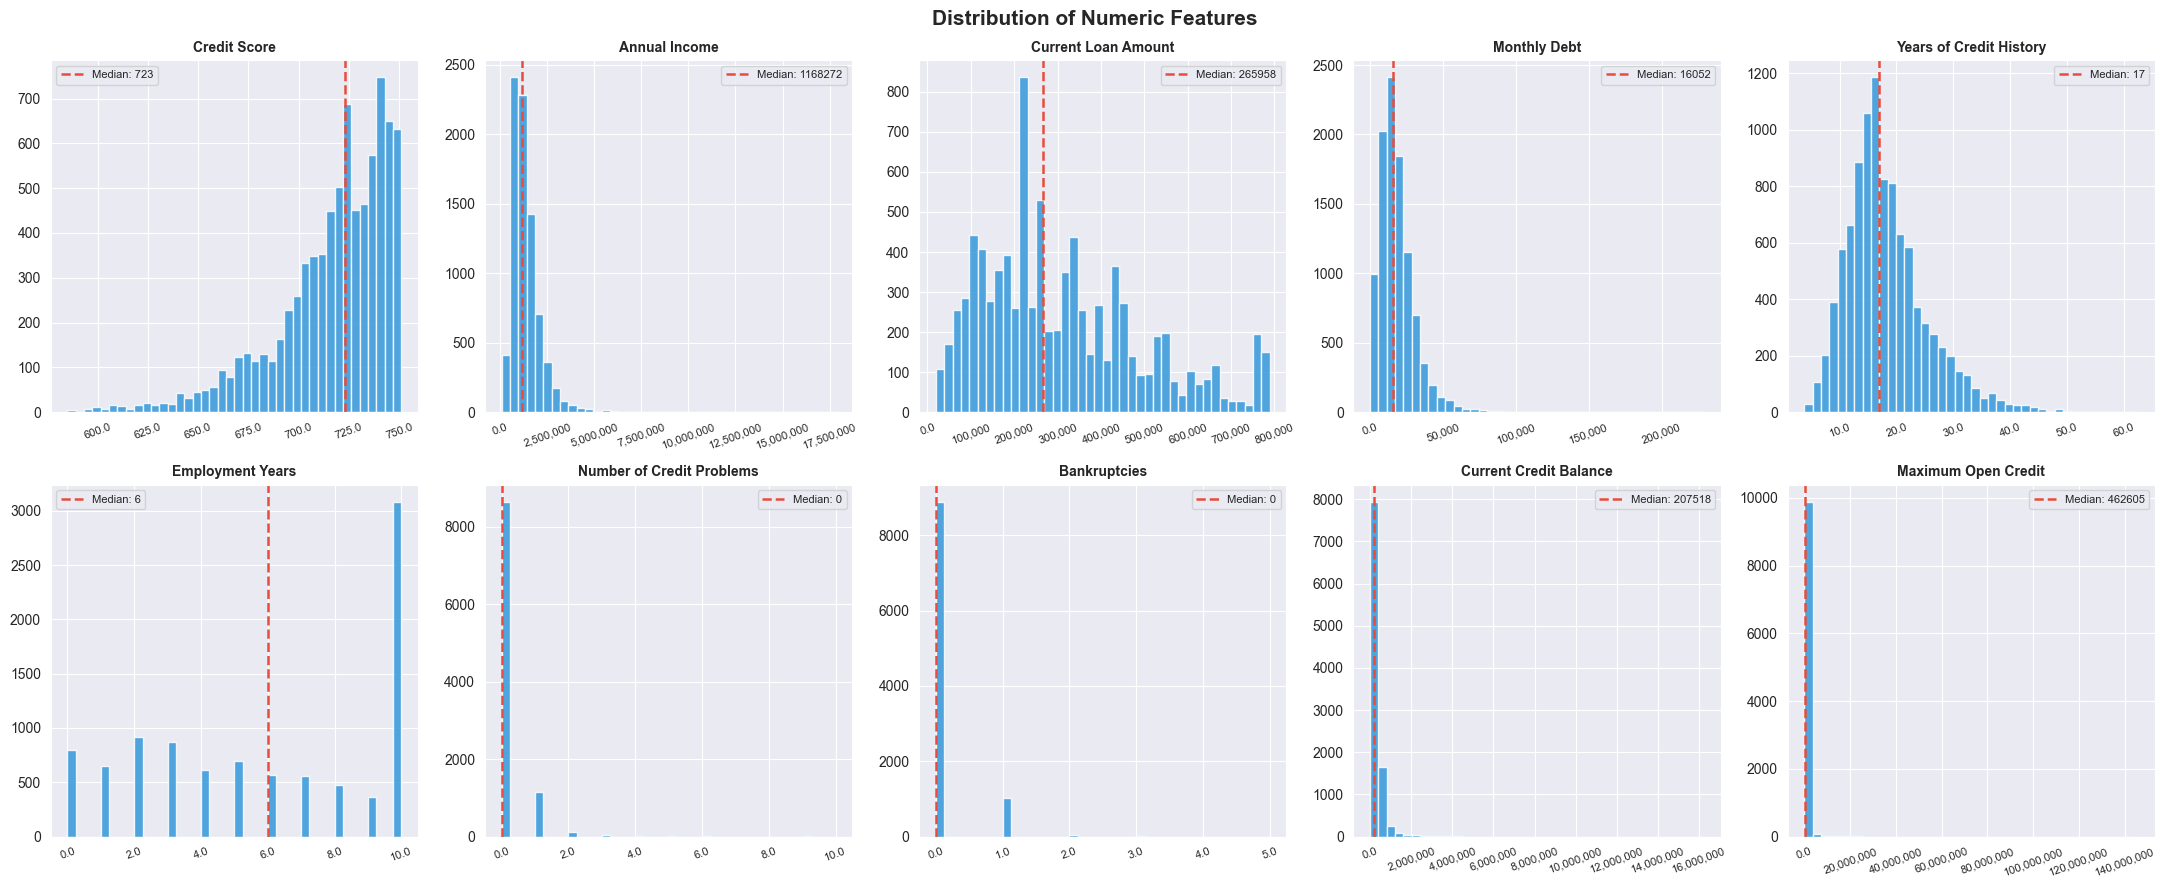

In [16]:
numeric_cols = ["Credit Score", "Annual Income", "Current Loan Amount",
                "Monthly Debt", "Years of Credit History", "Employment Years",
                "Number of Credit Problems", "Bankruptcies",
                "Current Credit Balance", "Maximum Open Credit"]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle("Distribution of Numeric Features", fontsize=15, fontweight="bold")

for ax, col in zip(axes.flat, numeric_cols):
    data = df[col].dropna()
    ax.hist(data, bins=40, color="#3498DB", edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="#E74C3C", lw=1.8, linestyle="--", label=f"Median: {data.median():.0f}")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}" if x >= 1000 else f"{x:.1f}"))
    ax.tick_params(axis="x", rotation=20, labelsize=8)

plt.tight_layout()
plt.show()



### 3.2 Categorical Features


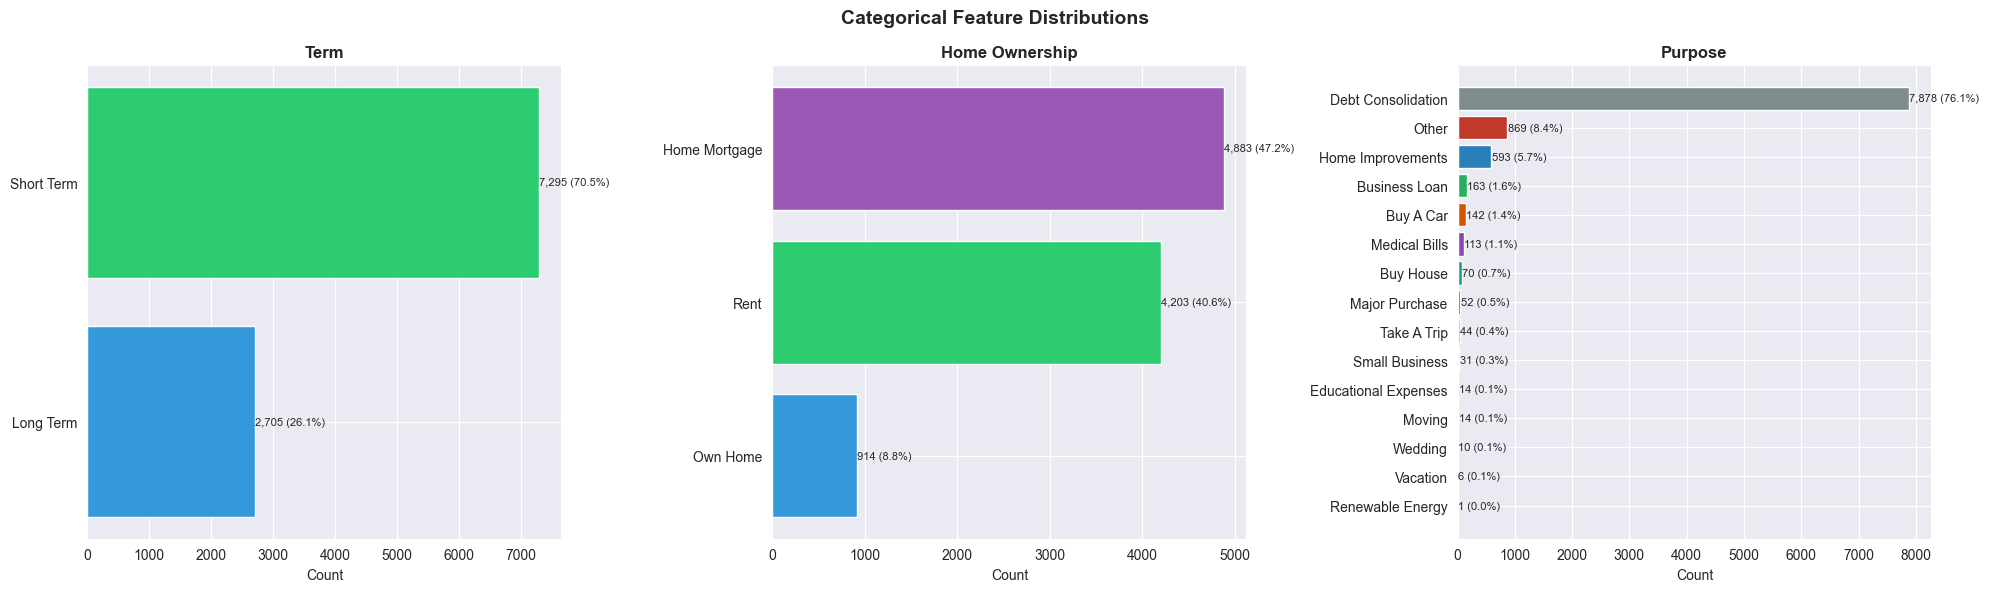

In [17]:
cat_cols = ["Term", "Home Ownership", "Purpose"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
colors_cat = ["#3498DB", "#2ECC71", "#9B59B6", "#E67E22",
              "#1ABC9C", "#E74C3C", "#F39C12", "#34495E",
              "#16A085", "#8E44AD", "#D35400", "#27AE60",
              "#2980B9", "#C0392B", "#7F8C8D", "#BDC3C7"]

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts().head(16)
    n = len(counts)
    ax.barh(counts.index[::-1], counts.values[::-1],
            color=colors_cat[:n], edgecolor="white")
    for i, (val, label) in enumerate(zip(counts.values[::-1], counts.index[::-1])):
        ax.text(val + 5, i, f"{val:,} ({val/len(df)*100:.1f}%)", va="center", fontsize=8)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.show()



### 3.3 Correlation Heatmap


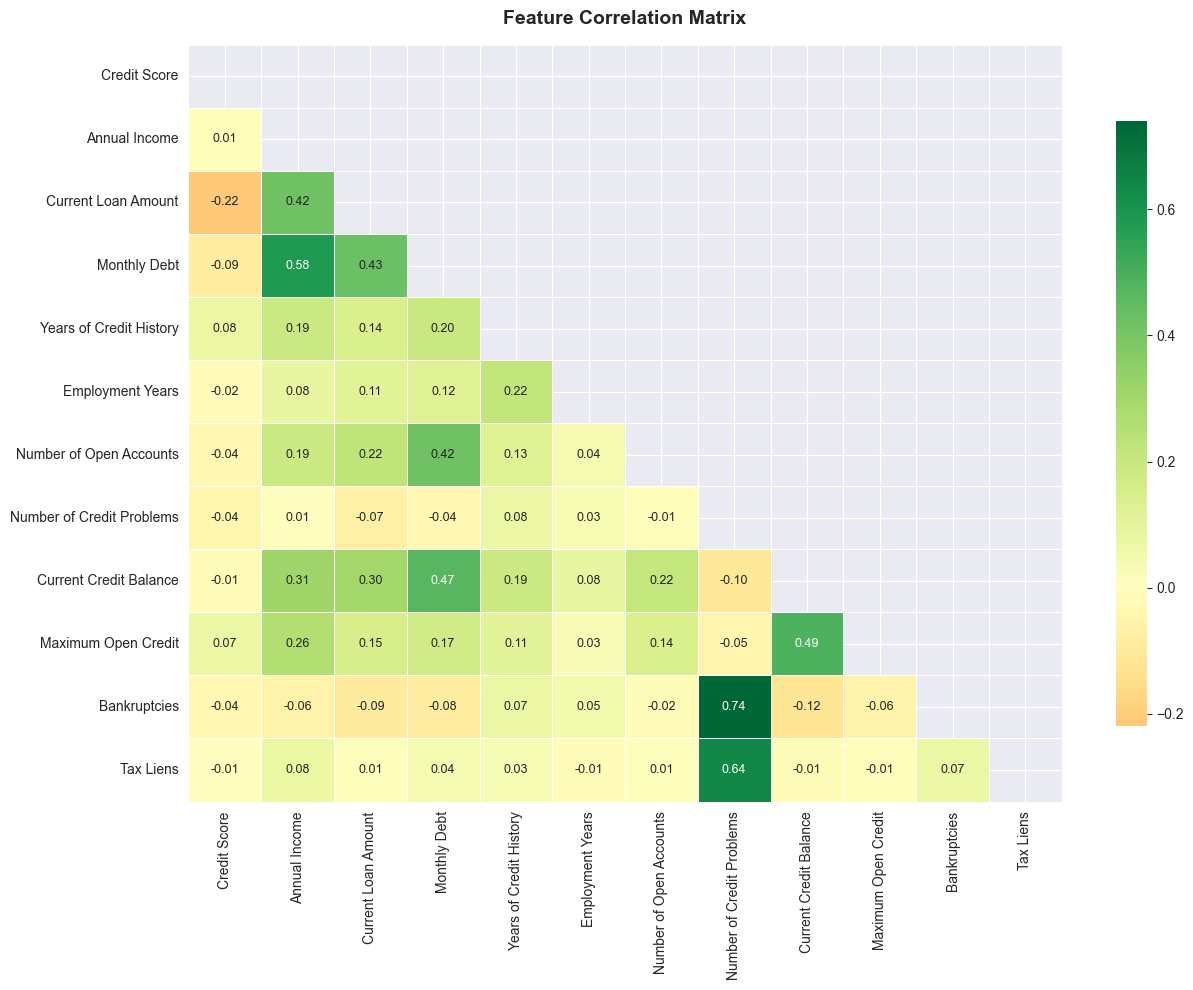

In [18]:
corr_cols = ["Credit Score", "Annual Income", "Current Loan Amount",
             "Monthly Debt", "Years of Credit History", "Employment Years",
             "Number of Open Accounts", "Number of Credit Problems",
             "Current Credit Balance", "Maximum Open Credit",
             "Bankruptcies", "Tax Liens"]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 9})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()



### 3.4 Outlier Analysis — Box Plots


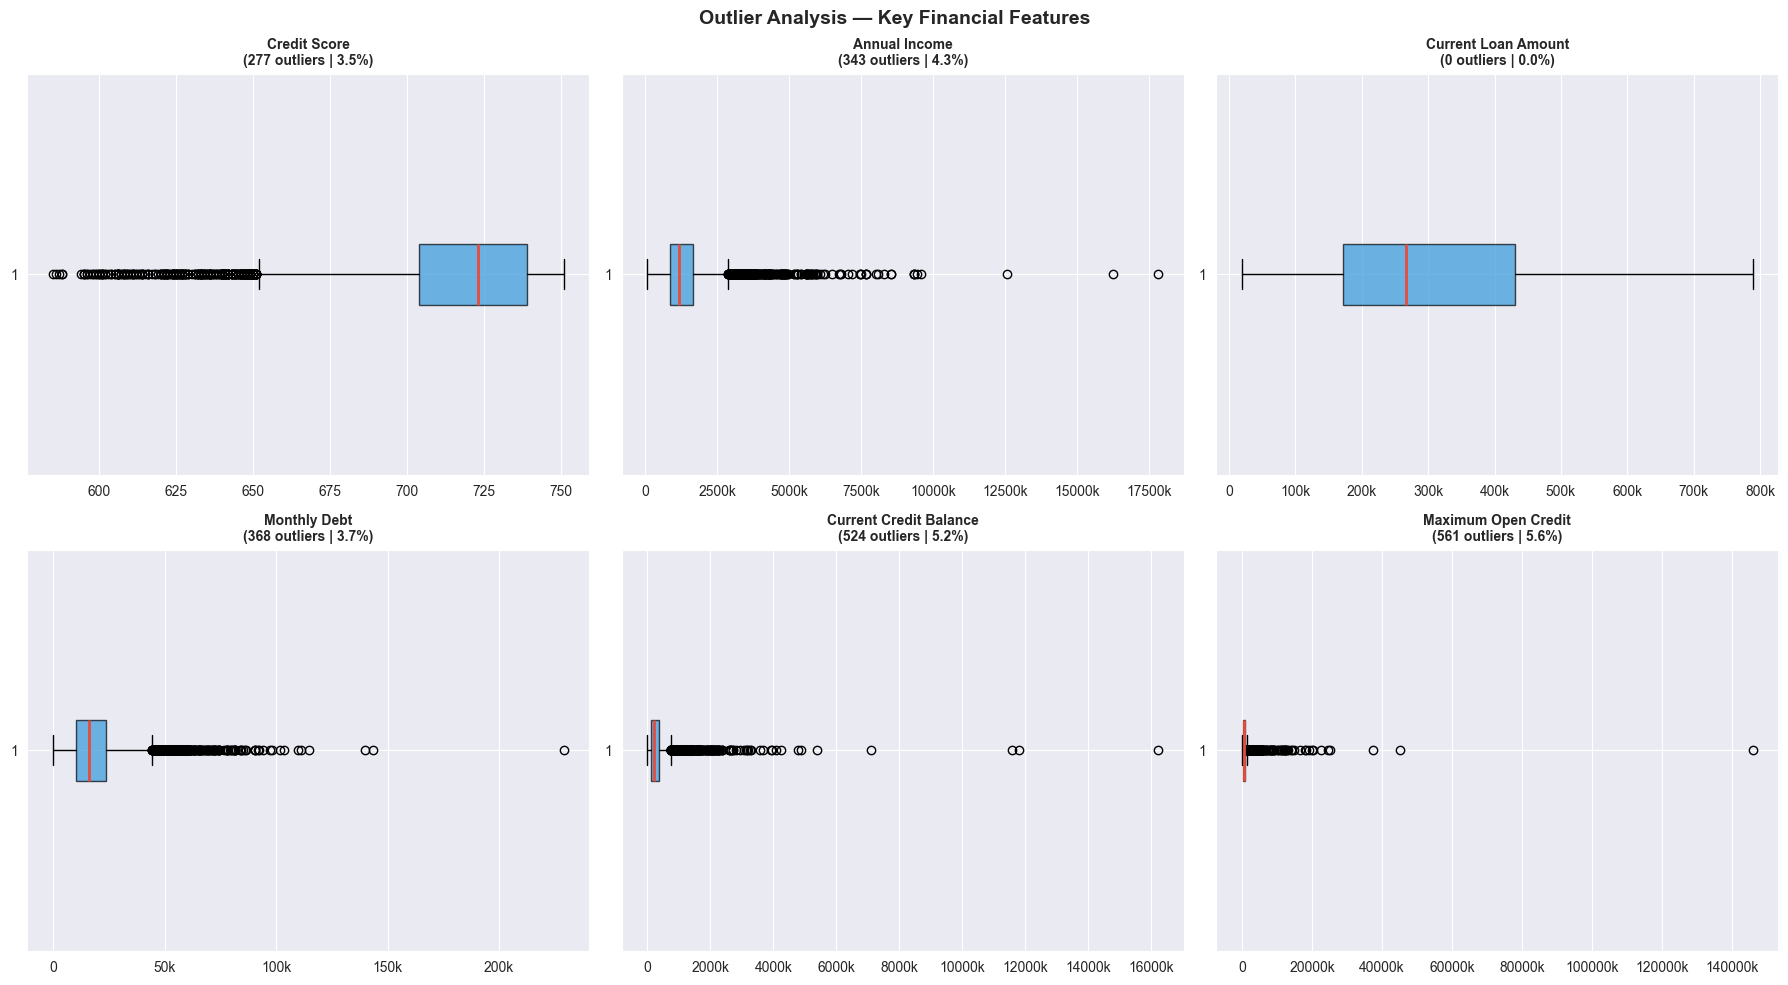

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Outlier Analysis — Key Financial Features", fontsize=14, fontweight="bold")

box_cols = ["Credit Score", "Annual Income", "Current Loan Amount",
            "Monthly Debt", "Current Credit Balance", "Maximum Open Credit"]

for ax, col in zip(axes.flat, box_cols):
    data = df[col].dropna()
    bp = ax.boxplot(data, patch_artist=True, vert=False,
                    medianprops=dict(color="#E74C3C", linewidth=2))
    bp["boxes"][0].set_facecolor("#3498DB")
    bp["boxes"][0].set_alpha(0.7)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_title(f"{col}\n({n_outliers:,} outliers | {n_outliers/len(data)*100:.1f}%)",
                 fontsize=10, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k" if x >= 1000 else f"{x:.0f}"))

plt.tight_layout()
plt.show()



## 4.  Feature Engineering & Target Construction

### 4.1 New Features


In [20]:
df_feat = df.copy()

#  Debt-to-Income Ratio (DTI) 
annual_debt = df_feat["Monthly Debt"] * 12
df_feat["DTI Ratio"] = (annual_debt / df_feat["Annual Income"]).round(4)

#  Loan-to-Income Ratio 
df_feat["Loan To Income"] = (df_feat["Current Loan Amount"] / df_feat["Annual Income"]).round(4)

#  Credit Utilization 
df_feat["Credit Utilization"] = (df_feat["Current Credit Balance"] /
                                  df_feat["Maximum Open Credit"].replace(0, np.nan)).round(4)

#  Has Delinquent (binary) 
df_feat["Has Delinquent"] = df_feat["Months since last delinquent"].notna().astype(int)

#  Long Term Loan (binary) 
df_feat["Long Term"] = (df_feat["Term"] == "Long Term").astype(int)

#  Is Property Owner 
df_feat["Is Owner"] = df_feat["Home Ownership"].isin(["Own Home", "Home Mortgage"]).astype(int)

print("New features created:")
new_features = ["DTI Ratio","Loan To Income","Credit Utilization","Has Delinquent","Long Term","Is Owner"]
print(df_feat[new_features].describe().T[["count","mean","min","max"]].round(3).to_string())



New features created:
                      count   mean    min    max
DTI Ratio            8019.0  0.173  0.000  0.400
Loan To Income       6886.0  0.253  0.005  0.758
Credit Utilization   9938.0  0.483  0.001  0.975
Has Delinquent      10353.0  0.453  0.000  1.000
Long Term           10353.0  0.261  0.000  1.000
Is Owner            10353.0  0.560  0.000  1.000


### 4.2 Risk-Based Target Construction

> **Since this dataset has no `Loan Status` column** (it is a test split), we engineer a
> risk-based binary target using standard banking credit scoring rules.  
> A customer is labelled **Low Risk (1 = Approve)** if they meet the majority of criteria:

| Criterion | Threshold | Weight |
|-----------|-----------|--------|
| Credit Score | ≥ 680 | 30 pts |
| DTI Ratio | < 0.40 | 25 pts |
| No Credit Problems | = 0 | 20 pts |
| No Bankruptcies | = 0 | 15 pts |
| Employment ≥ 2 yrs | ≥ 2 | 10 pts |

**Threshold:** Score ≥ 50 → Approve (Low Risk)



In [21]:
PALETTE  = {1: "#2ECC71", 0: "#E74C3C"}
LABEL    = {1: "Low Risk (Approve)", 0: "High Risk (Reject)"}

Approval rate  : 75.9%
Approved       : 7,854
Rejected       : 2,499


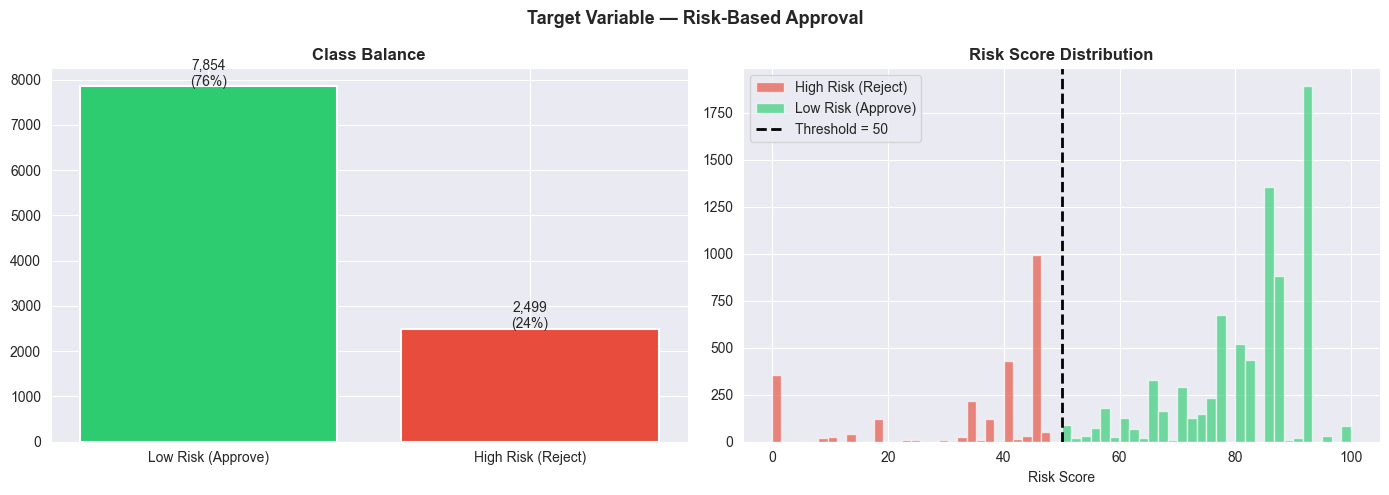

In [22]:
def compute_risk_score(row):
    score = 0
    # Credit score (30 pts)
    cs = row.get("Credit Score", np.nan)
    if not pd.isna(cs):
        if   cs >= 750: score += 30
        elif cs >= 700: score += 22
        elif cs >= 680: score += 15
        elif cs >= 620: score += 8

    # DTI Ratio (25 pts)
    dti = row.get("DTI Ratio", np.nan)
    if not pd.isna(dti):
        if   dti < 0.20: score += 25
        elif dti < 0.30: score += 18
        elif dti < 0.40: score += 10
        elif dti < 0.50: score += 5

    # Credit problems (20 pts)
    cp = row.get("Number of Credit Problems", np.nan)
    if not pd.isna(cp):
        if   cp == 0: score += 20
        elif cp == 1: score += 8

    # Bankruptcies (15 pts)
    bk = row.get("Bankruptcies", np.nan)
    if not pd.isna(bk):
        if bk == 0: score += 15

    # Employment years (10 pts)
    ey = row.get("Employment Years", np.nan)
    if not pd.isna(ey):
        if   ey >= 5: score += 10
        elif ey >= 2: score += 6
        elif ey >= 1: score += 3

    return score

df_feat["Risk Score"]   = df_feat.apply(compute_risk_score, axis=1)
df_feat["Approved"]     = (df_feat["Risk Score"] >= 50).astype(int)

approval_rate = df_feat["Approved"].mean()
print(f"Approval rate  : {approval_rate:.1%}")
print(f"Approved       : {df_feat['Approved'].sum():,}")
print(f"Rejected       : {(df_feat['Approved']==0).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Target Variable — Risk-Based Approval", fontsize=13, fontweight="bold")

# Distribution
counts = df_feat["Approved"].value_counts()
bars = axes[0].bar([LABEL[k] for k in counts.index],
                   counts.values,
                   color=[PALETTE[k] for k in counts.index],
                   edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"{val:,}\n({val/len(df_feat):.0%})", ha="center", fontsize=10)
axes[0].set_title("Class Balance", fontweight="bold")

# Risk score histogram by class
for label, grp in df_feat.groupby("Approved"):
    axes[1].hist(grp["Risk Score"], bins=30, alpha=0.65,
                 color=PALETTE[label], label=LABEL[label], edgecolor="white")
axes[1].axvline(50, color="black", lw=2, linestyle="--", label="Threshold = 50")
axes[1].set_title("Risk Score Distribution", fontweight="bold")
axes[1].set_xlabel("Risk Score")
axes[1].legend()

plt.tight_layout()
plt.show()



### 4.3 EDA by Approval Status


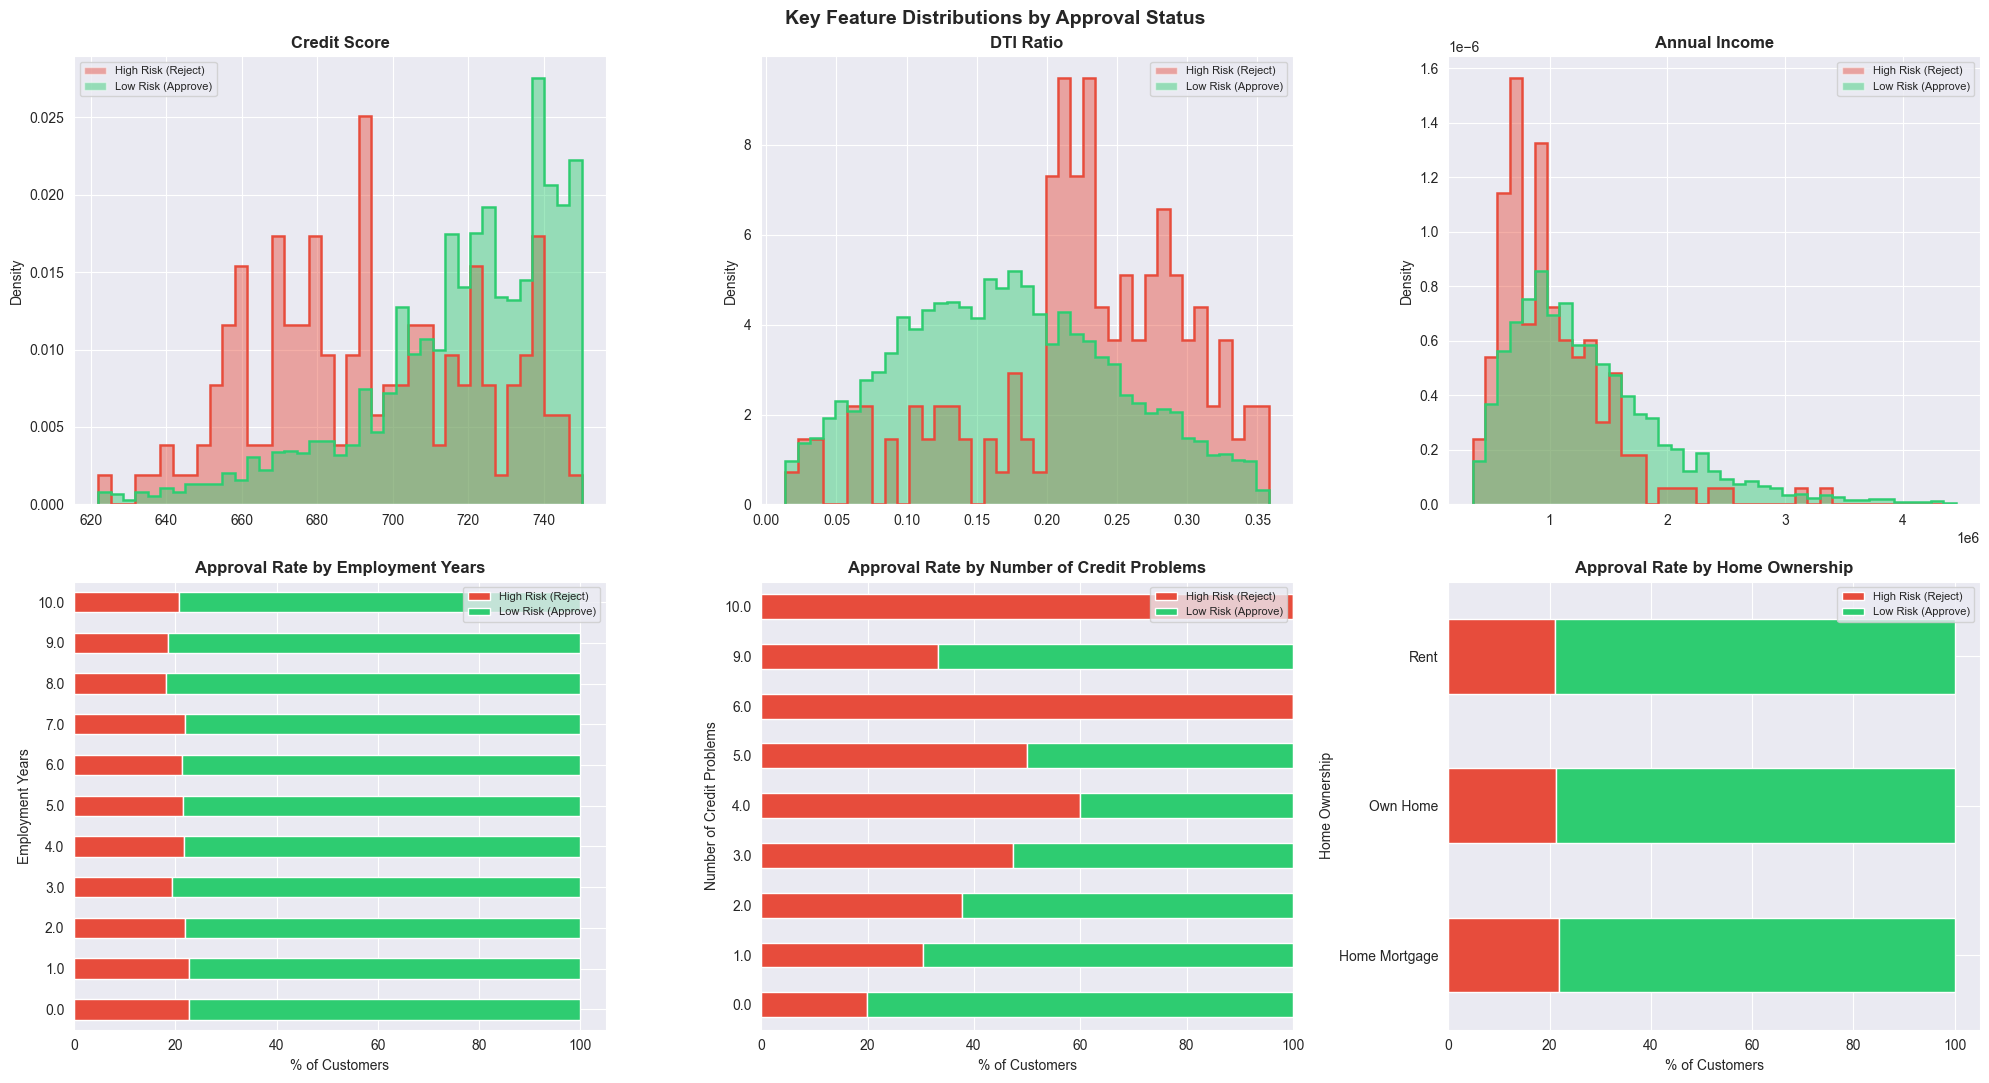

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Key Feature Distributions by Approval Status", fontsize=14, fontweight="bold")

compare_cols = [
    ("Credit Score",              "histogram"),
    ("DTI Ratio",                 "histogram"),
    ("Annual Income",             "histogram"),
    ("Employment Years",          "bar"),
    ("Number of Credit Problems", "bar"),
    ("Home Ownership",            "bar"),
]

for ax, (col, chart_type) in zip(axes.flat, compare_cols):
    if chart_type == "histogram":
        all_data = df_feat[col].dropna()
        bins = np.linspace(all_data.quantile(0.01), all_data.quantile(0.99), 40)

        for label, grp in df_feat.groupby("Approved"):
            data = grp[col].dropna()
            # density=True normalizes each group independently — imbalanced classes no longer hide each other
            ax.hist(data, bins=bins, density=True, alpha=0.45,
                    color=PALETTE[label], histtype="stepfilled", label=LABEL[label])
            ax.hist(data, bins=bins, density=True, alpha=1.0,
                    color=PALETTE[label], histtype="step", linewidth=1.8)

        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
    else:
        tbl = df_feat.groupby([col, "Approved"]).size().unstack(fill_value=0)
        tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
        tbl_pct[[0, 1]].plot(kind="barh", ax=ax, stacked=True,
                             color=[PALETTE[0], PALETTE[1]],
                             edgecolor="white")
        ax.set_title(f"Approval Rate by {col}", fontweight="bold")
        ax.set_xlabel("% of Customers")
        ax.legend([LABEL[0], LABEL[1]], fontsize=8)

plt.tight_layout()
plt.show()

In [29]:
import os

# Save cleaned data
output_dir = "../data"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "credit_eda.csv")

df_feat.to_csv(csv_path, index=False)

print(f"Saved CSV     : {csv_path}")


Saved CSV     : ../data\credit_eda.csv
